**Student Performance Prediction Using Machine Learning**


Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


Load Dataset

In [11]:
df = pd.read_csv("student-mat.csv", sep=";")

In [12]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [13]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0



Encode Categorical Data

In [14]:
encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = encoder.fit_transform(df[column])

In [16]:
X = df.drop("G3", axis=1)

y = df["G3"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
lr = LinearRegression()

lr.fit(X_train, y_train)

prediction_lr = lr.predict(X_test)

Evaluate Linear Regression

In [19]:
print("R2 Score:", r2_score(y_test, prediction_lr))

print("MAE:", mean_absolute_error(y_test, prediction_lr))

print("MSE:", mean_squared_error(y_test, prediction_lr))

R2 Score: 0.7545777855043501
MAE: 1.4954750100522765
MSE: 5.03239410886674


In [20]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

prediction_dt = dt.predict(X_test)

Evaluate Decision Tree

In [21]:
print("R2:", r2_score(y_test, prediction_dt))

print("MAE:", mean_absolute_error(y_test, prediction_dt))

print("MSE:", mean_squared_error(y_test, prediction_dt))

R2: 0.7240568249304535
MAE: 1.3037974683544304
MSE: 5.658227848101266


In [22]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

prediction_rf = rf.predict(X_test)

Evaluate Random Forest

In [23]:
print("R2:", r2_score(y_test, prediction_rf))

print("MAE:", mean_absolute_error(y_test, prediction_rf))

print("MSE:", mean_squared_error(y_test, prediction_rf))

R2: 0.8299569015097052
MAE: 1.1050632911392408
MSE: 3.4867417721518983


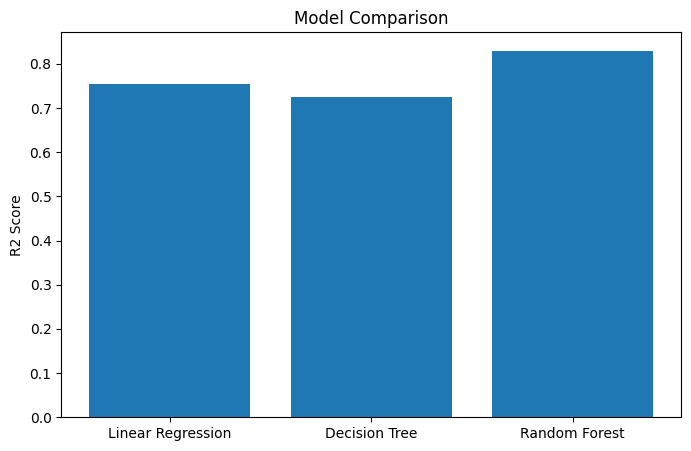

In [24]:
models = ['Linear Regression',
          'Decision Tree',
          'Random Forest']

scores = [

    r2_score(y_test, prediction_lr),

    r2_score(y_test, prediction_dt),

    r2_score(y_test, prediction_rf)

]

plt.figure(figsize=(8,5))
plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("R2 Score")
plt.show()

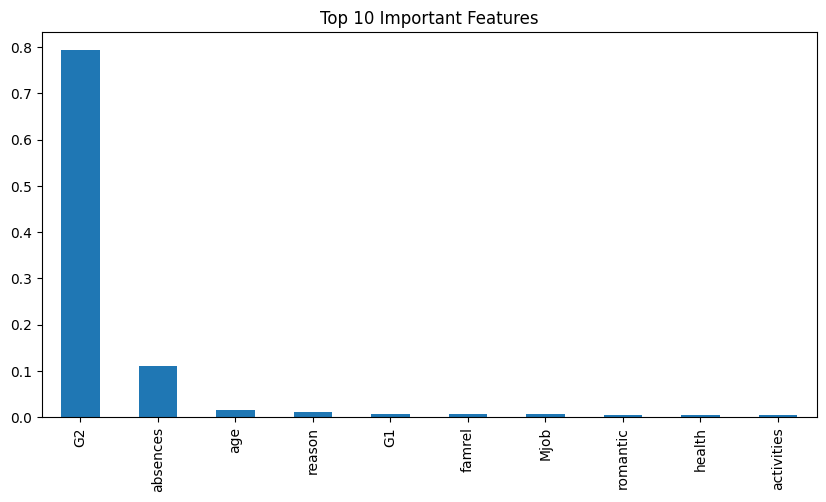

In [25]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Important Features")
plt.show()

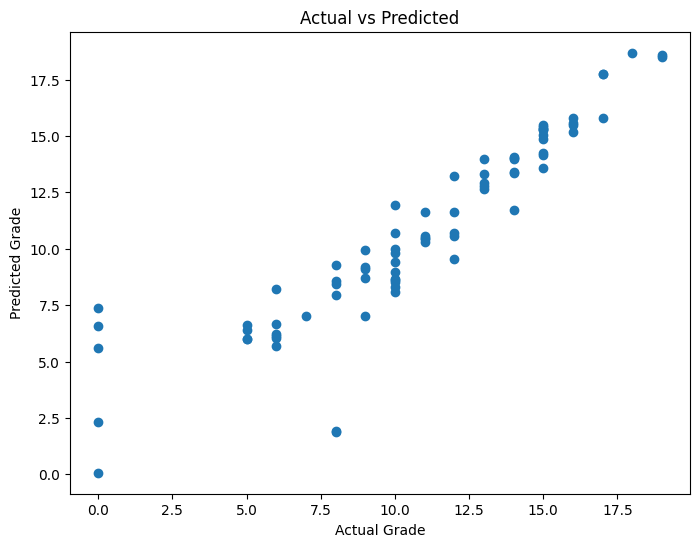

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, prediction_rf)

plt.xlabel("Actual Grade")

plt.ylabel("Predicted Grade")

plt.title("Actual vs Predicted")

plt.show()